## Objective

This notebook evaluates how the Aggressive Growth, Balanced Growth, and Resilient Growth portfolios behaved during several periods of significant historical market stress.

Unlike Notebook 3, which evaluates risk and performance over the full historical sample, this analysis focuses on specific adverse market environments. The goal is to compare the severity of portfolio losses, drawdowns, and recovery periods across different types of market shocks.

All scenario results use the constant-weight portfolio return series constructed in Notebook 2 and therefore inherit the simplifying rebalancing assumptions described there.

## Historical Stress Testing Scenarios

| Historical Event | Selected Analysis Window | Primary Risk Evaluated | Reason for Inclusion |
|------------------|-----------------|------------------------|----------------------|
| Global Financial Crisis | Oct. 2007 – Mar. 2009 | Credit, liquidity, and systemic financial risk | Benchmark historical stress event and largest financial crisis in modern history. |
| European Sovereign Debt Crisis | Apr. 2010 – Oct. 2011 | Sovereign debt and global market contagion | Evaluates the impact of sovereign debt concerns on globally diversified portfolios. |
| COVID-19 Market Crash | Feb. 19, 2020 – Mar. 23, 2020 | Global economic shutdown and extreme market volatility | Tests portfolio resilience during a rapid global market decline.. |
| Inflation & Interest Rate Bear Market | Jan. 2022 – Oct. 2022 | Inflation and rising interest rates | Evaluates performance during a period when both equities and bonds declined simultaneously. |

These events represent different sources of market stress, including systemic financial instability, sovereign-debt concerns, sudden global economic disruption, and inflation-driven monetary tightening.Evaluating portfolio performance across multiple historical environments provides a more comprehensive assessment of portfolio resilience than relying solely on long-term performance metrics.


Each event is evaluated using the same general framework: cumulative portfolio return over the selected stress window, the path of a hypothetical $100 investment, maximum drawdown, and the time required to recover the portfolio's previous peak. Applying the same framework across different environments allows the resilience of the three strategic allocations to be compared more consistently.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#Load portfolio returns
portfolio_returns = pd.read_csv(
    "portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

#Reconstruct portfolio values
growth = (1 + portfolio_returns).cumprod() * 100

# Create a $100 starting value immediately before each stress window
def growth_of_100_with_start(event_returns):
    growth = (1 + event_returns).cumprod() * 100

    first_event_date = event_returns.index[0]

    previous_dates = portfolio_returns.index[
        portfolio_returns.index < first_event_date
    ]

    start_date = previous_dates[-1]

    starting_row = pd.DataFrame(
        [[100] * len(growth.columns)],
        columns=growth.columns,
        index=[start_date]
    )

    return pd.concat([starting_row, growth])

**Recovery-period convention:** Recovery Days and Drawdown Duration are measured in calendar days between the identified dates. Year equivalents are calculated using 365.25 days per year.

## Global Financial Crisis (Oct.2007 - Mar.2009)

The Global Financial Crisis (GFC) was the most severe financial crisis since the Great Depression and resulted from the collapse of the U.S. housing market, widespread defaults on subprime mortgages, and failures within the global banking system. 

The Global Financial Crisis provides a severe systemic stress environment involving large equity-market declines, credit deterioration, liquidity pressure, and significant disruption across the financial system. It is included to evaluate how the three strategic allocations performed during a prolonged and broad-based financial crisis.

Comparing portfolio performance during this period provides insight into downside protection, portfolio resilience, and the trade-offs associated with different levels of equity exposure.

### Selected Event Window

The selected stress window runs from October 1, 2007 through March 31, 2009. Portfolio performance is evaluated over the common event window, while each portfolio's own peak, trough, and subsequent recovery date are identified separately.

Portfolio-specific peak and trough dates are identified independently to capture differences in drawdown behavior resulting from each portfolio's strategic asset allocation. Recovery dates are subsequently identified as the first date on which each portfolio regains its respective pre-drawdown peak.


In [2]:
#Event Retuns
gfc_start = "2007-10-01"
gfc_end = "2009-03-31"

gfc_returns = portfolio_returns.loc[gfc_start:gfc_end]

In [3]:
gfc_cumulative_return = (1 + gfc_returns).prod() - 1

gfc_cumulative_return_df = (
    gfc_cumulative_return
    .to_frame(name="Cumulative Return")
    .style
    .format("{:.2%}")
)

gfc_cumulative_return_df

,Cumulative Return
Aggressive,-39.91%
Balanced,-29.56%
Resilient,-14.60%


### Growth of $100 Invested 

To illustrate the economic impact of the Global Financial Crisis, the following figure tracks the value of a hypothetical $100 investment in each portfolio over the stress period. This visualization provides an intuitive comparison of the magnitude and path of portfolio losses during the crisis.

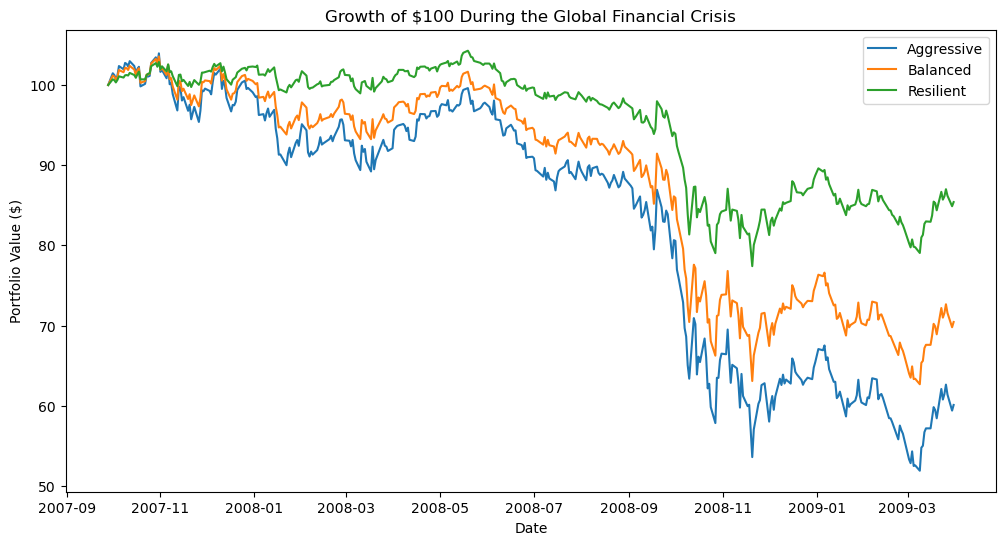

,Aggressive,Balanced,Resilient
2009-03-25 00:00:00,61.44,71.55,86.11
2009-03-26 00:00:00,62.63,72.66,87.01
2009-03-27 00:00:00,61.39,71.57,86.19
2009-03-30 00:00:00,59.39,69.79,84.88
2009-03-31 00:00:00,60.09,70.44,85.40


In [4]:
# Growth of $100 during the Global Financial Crisis
gfc_growth = growth_of_100_with_start(gfc_returns)

plt.figure(figsize=(12,6))

for column in gfc_growth.columns:
    plt.plot(gfc_growth.index, 
             gfc_growth[column], 
             label=column)

plt.title("Growth of $100 During the Global Financial Crisis")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()

plt.show()
gfc_growth.tail().style.format("{:.2f}")

In [5]:
#Calculate running maximum
gfc_running_max = gfc_growth.cummax()

#Calculate Drawdowns
gfc_drawdown = (gfc_growth - gfc_running_max) / gfc_running_max

#Calculate Maximum Drawdown
gfc_max_drawdown = gfc_drawdown.min()

# Display results
gfc_max_drawdown_df = (
    gfc_max_drawdown
    .to_frame(name="Maximum Drawdown")
    .style
    .format("{:.2%}")
)

gfc_max_drawdown_df

,Maximum Drawdown
Aggressive,-50.09%
Balanced,-39.49%
Resilient,-25.77%


In [6]:
# Define GFC window
gfc_start = "2007-10-01"
gfc_end = "2009-03-31"

gfc_drawdown_analysis = []

for portfolio in portfolio_returns.columns:

    # Build an extended GFC series starting at the event
    # and continuing through the rest of the dataset
    extended_returns = portfolio_returns.loc[
        gfc_start:,
        [portfolio]
    ]

    extended_growth = growth_of_100_with_start(
        extended_returns
    )[portfolio]

    # Restrict to GFC window for peak/trough analysis
    event_growth = extended_growth.loc[:gfc_end]

    # Running peak during the event
    running_peak = event_growth.cummax()

    # Drawdown series
    event_drawdown = (event_growth - running_peak) / running_peak

    # Trough = date of maximum drawdown
    trough_date = event_drawdown.idxmin()

    # Peak associated with that trough
    pre_trough_growth = event_growth.loc[:trough_date]
    peak_date = pre_trough_growth.idxmax()
    peak_value = pre_trough_growth.loc[peak_date]

    # Continue beyond GFC window using the SAME rebased series
    after_trough = extended_growth.loc[trough_date:]

    # First date the portfolio returns to or exceeds the prior peak
    recovery_series = after_trough[after_trough >= peak_value]

    if len(recovery_series) > 0:
        recovery_date = recovery_series.index[0]

        recovery_days = (recovery_date - trough_date).days
        drawdown_duration = (recovery_date - peak_date).days
    else:
        recovery_date = pd.NaT
        recovery_days = np.nan
        drawdown_duration = np.nan

    # Maximum drawdown
    max_drawdown = event_drawdown.min()

    gfc_drawdown_analysis.append({
        "Portfolio": portfolio,
        "Maximum Drawdown": max_drawdown,
        "Peak Date": peak_date,
        "Trough Date": trough_date,
        "Recovery Date": recovery_date,
        "Recovery Days": recovery_days,
        "Drawdown Duration": drawdown_duration
    })

# Convert to DataFrame
gfc_drawdown_df = pd.DataFrame(gfc_drawdown_analysis)

# Format dates without timestamps
date_columns = ["Peak Date", "Trough Date", "Recovery Date"]

for col in date_columns:
    gfc_drawdown_df[col] = pd.to_datetime(
        gfc_drawdown_df[col]
    ).dt.strftime("%Y-%m-%d")

# Display formatted table
gfc_drawdown_df.style.hide(axis="index").format({
    "Maximum Drawdown": "{:.2%}",
    "Recovery Days": "{:.0f}",
    "Drawdown Duration": "{:.0f}"
})

Portfolio,Maximum Drawdown,Peak Date,Trough Date,Recovery Date,Recovery Days,Drawdown Duration
Aggressive,-50.09%,2007-10-31,2009-03-09,2011-02-16,709,1204
Balanced,-39.49%,2007-10-31,2009-03-09,2010-10-06,576,1071
Resilient,-25.77%,2008-05-19,2008-11-20,2009-10-14,328,513


In [7]:
# Convert recovery periods to years
gfc_drawdown_df["Recovery Years"] = (
    gfc_drawdown_df["Recovery Days"] / 365.25
)

gfc_drawdown_df["Drawdown Duration Years"] = (
    gfc_drawdown_df["Drawdown Duration"] / 365.25
)
gfc_drawdown_df.style.hide(axis="index").format({
    "Maximum Drawdown": "{:.2%}",
    "Drawdown Duration": "{:.0f}",
    "Recovery Years": "{:.2f}",
    "Drawdown Duration Years": "{:.2f}"
})

Portfolio,Maximum Drawdown,Peak Date,Trough Date,Recovery Date,Recovery Days,Drawdown Duration,Recovery Years,Drawdown Duration Years
Aggressive,-50.09%,2007-10-31,2009-03-09,2011-02-16,709,1204,1.94,3.30
Balanced,-39.49%,2007-10-31,2009-03-09,2010-10-06,576,1071,1.58,2.93
Resilient,-25.77%,2008-05-19,2008-11-20,2009-10-14,328,513,0.90,1.40


### Interpretation

The Global Financial Crisis produced the most severe losses and longest recovery periods among the historical scenarios examined. Aggressive Growth experienced the largest cumulative loss and deepest maximum drawdown, while Resilient Growth experienced the smallest decline.

The recovery analysis adds another important distinction. Aggressive Growth required the longest period to recover from its trough and spent the greatest amount of time below its previous peak. Resilient Growth experienced both a smaller drawdown and a substantially shorter recovery period, with Balanced Growth remaining between the two.

In this environment, the results are consistent with the more defensive allocations providing greater protection against both the severity and duration of the market decline.

## European Sovereign Debt Crisis — Acute 2010 Selloff (Apr. 2010 - Oct. 2011)
The European Sovereign Debt Crisis developed as concerns over government debt sustainability intensified across several euro-area countries, particularly Greece, Ireland, Portugal, Spain, and Italy. Rising sovereign borrowing costs, banking-sector vulnerabilities, and concerns regarding the stability of the euro area contributed to heightened financial-market volatility and declines in global equity markets. This scenario provides an opportunity to evaluate how the three portfolios responded to a crisis centered outside the United States and involving significant sovereign-credit and international equity risk.

### Purpose
This historical stress scenario evaluates the performance and resilience of the Aggressive, Balanced, and Resilient Growth portfolios during the European Sovereign Debt Crisis. The analysis is particularly useful for assessing whether diversification across international equities provided protection or increased portfolio exposure during a period of significant European market stress.

### Event Window Methodology
The European Sovereign Debt Crisis extended across multiple years and included several distinct periods of financial-market stress. For this historical stress test, the event window is defined as April 23, 2010 through July 2, 2010, representing an acute market selloff associated with escalating concerns over Greek sovereign debt and potential contagion across European financial markets. Portfolio performance is evaluated over this common stress window, while portfolio-specific peak and trough dates are identified for drawdown analysis. Recovery is measured beyond the event window until each portfolio regains its respective pre-drawdown peak.

In [8]:
# Define European Sovereign Debt Crisis window
euro_start = "2010-04-23"
euro_end = "2010-07-02"

# Extract portfolio returns during the crisis
euro_returns = portfolio_returns.loc[euro_start:euro_end]

In [9]:
# Calculate cumulative return
euro_cumulative_return = (1 + euro_returns).prod() - 1

# Display results
euro_cumulative_return_df = (
    euro_cumulative_return
    .to_frame(name="Cumulative Return")
    .style
    .format("{:.2%}")
)

euro_cumulative_return_df

,Cumulative Return
Aggressive,-11.99%
Balanced,-8.40%
Resilient,-3.94%


### Growth of $100 Invested 

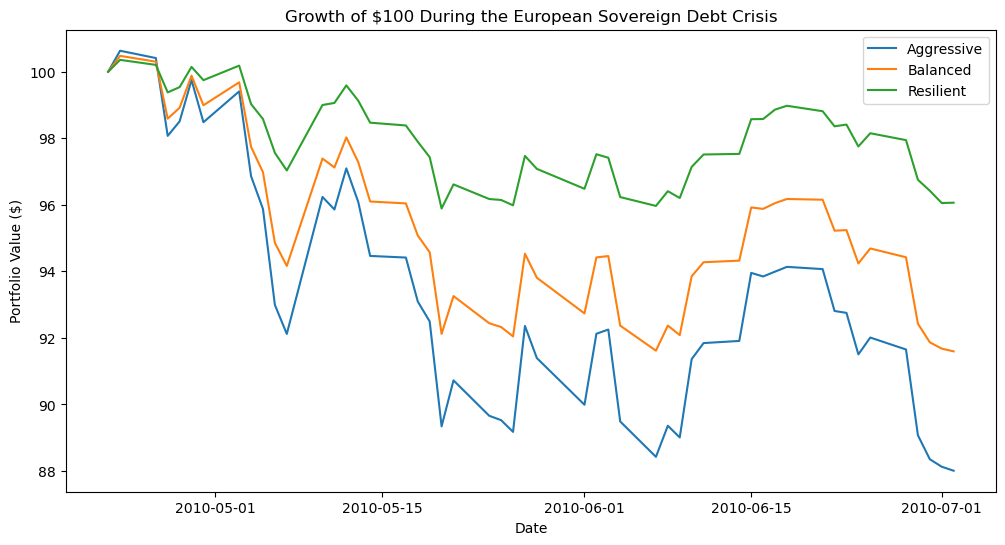

,Aggressive,Balanced,Resilient
2010-06-28 00:00:00,91.65,94.42,97.95
2010-06-29 00:00:00,89.07,92.43,96.75
2010-06-30 00:00:00,88.35,91.87,96.42
2010-07-01 00:00:00,88.13,91.68,96.05
2010-07-02 00:00:00,88.01,91.60,96.06


In [10]:
# Growth of $100 during the European Sovereign Debt Crisis
euro_growth = growth_of_100_with_start(euro_returns)
plt.figure(figsize=(12, 6))

for column in euro_growth.columns:
    plt.plot(
        euro_growth.index,
        euro_growth[column],
        label=column
    )

plt.title("Growth of $100 During the European Sovereign Debt Crisis")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()

plt.show()
euro_growth.tail().style.format("{:.2f}")

In [11]:
# Calculate running maximum
euro_running_max = euro_growth.cummax()

# Calculate drawdowns
euro_drawdown = (
    euro_growth - euro_running_max
) / euro_running_max

# Calculate maximum drawdown
euro_max_drawdown = euro_drawdown.min()

# Display results
euro_max_drawdown_df = (
    euro_max_drawdown
    .to_frame(name="Maximum Drawdown")
    .style
    .format("{:.2%}")
)

euro_max_drawdown_df

,Maximum Drawdown
Aggressive,-12.54%
Balanced,-8.84%
Resilient,-4.45%


In [12]:
# European Sovereign Debt Crisis drawdown analysis
euro_drawdown_analysis = []

for portfolio in portfolio_returns.columns:

    # Build an extended European crisis series starting at the event
    # and continuing through the rest of the dataset
    extended_returns = portfolio_returns.loc[
        euro_start:,
        [portfolio]
    ]

    extended_growth = growth_of_100_with_start(
        extended_returns
    )[portfolio]

    # Restrict to European crisis window for peak/trough analysis
    event_growth = extended_growth.loc[:euro_end]

    # Calculate running peak and drawdown
    running_peak = event_growth.cummax()
    event_drawdown = (event_growth - running_peak) / running_peak

    # Identify trough date (maximum drawdown)
    trough_date = event_drawdown.idxmin()

    # Identify peak associated with the trough
    pre_trough_growth = event_growth.loc[:trough_date]
    peak_date = pre_trough_growth.idxmax()
    peak_value = pre_trough_growth.loc[peak_date]

    # Continue beyond the event window using the SAME rebased series
    after_trough = extended_growth.loc[trough_date:]

    # First date portfolio returns to or exceeds prior peak
    recovery_series = after_trough[
        after_trough >= peak_value
    ]

    if len(recovery_series) > 0:
        recovery_date = recovery_series.index[0]

        recovery_days = (recovery_date - trough_date).days
        drawdown_duration = (recovery_date - peak_date).days

    else:
        recovery_date = pd.NaT
        recovery_days = np.nan
        drawdown_duration = np.nan

    # Maximum drawdown
    max_drawdown = event_drawdown.min()

    euro_drawdown_analysis.append({
        "Portfolio": portfolio,
        "Maximum Drawdown": max_drawdown,
        "Peak Date": peak_date,
        "Trough Date": trough_date,
        "Recovery Date": recovery_date,
        "Recovery Days": recovery_days,
        "Drawdown Duration": drawdown_duration
    })

# Convert results to DataFrame
euro_drawdown_df = pd.DataFrame(euro_drawdown_analysis)

# Remove timestamps from dates
date_columns = ["Peak Date", "Trough Date", "Recovery Date"]

for col in date_columns:
    euro_drawdown_df[col] = pd.to_datetime(
        euro_drawdown_df[col]
    ).dt.strftime("%Y-%m-%d")

In [13]:
# Convert recovery periods to years
euro_drawdown_df["Recovery Years"] = (
    euro_drawdown_df["Recovery Days"] / 365.25
)

euro_drawdown_df["Drawdown Duration Years"] = (
    euro_drawdown_df["Drawdown Duration"] / 365.25
)
#Display
euro_drawdown_df.style.hide(axis="index").format({
    "Maximum Drawdown": "{:.2%}",
    "Recovery Days": "{:.0f}",
    "Drawdown Duration": "{:.0f}",
    "Recovery Years": "{:.2f}",
    "Drawdown Duration Years": "{:.2f}"
})

Portfolio,Maximum Drawdown,Peak Date,Trough Date,Recovery Date,Recovery Days,Drawdown Duration,Recovery Years,Drawdown Duration Years
Aggressive,-12.54%,2010-04-23,2010-07-02,2010-10-05,95,165,0.26,0.45
Balanced,-8.84%,2010-04-23,2010-07-02,2010-09-24,84,154,0.23,0.42
Resilient,-4.45%,2010-04-23,2010-05-20,2010-08-02,74,101,0.20,0.28


### Interpretation

The selected European sovereign-debt stress period produced smaller losses than the Global Financial Crisis, but the same general ordering remained. Aggressive Growth experienced the greatest cumulative loss and maximum drawdown, Balanced Growth remained in the middle, and Resilient Growth experienced the smallest decline.

Recovery periods were also relatively short across all three strategies compared with the GFC. Resilient Growth reached its trough earlier and recovered its previous peak sooner than the other portfolios.

The results suggest that the more defensive allocation remained effective at limiting downside exposure during this episode, although the event was substantially less severe and shorter-lived than the Global Financial Crisis.

## Covid-19 Market Crash (2020)
The COVID-19 market crash occurred in early 2020 as the rapid global spread of COVID-19 created significant uncertainty regarding economic activity, corporate earnings, and global financial conditions. Widespread business closures, travel restrictions, and concerns surrounding the economic effects of the pandemic contributed to a rapid decline in global equity markets. Unlike the prolonged deterioration experienced during the Global Financial Crisis, the initial COVID-19 shock was characterized by an exceptionally rapid market decline followed by a comparatively rapid recovery.

### Purpose
This historical stress scenario evaluates the performance and resilience of the Aggressive, Balanced, and Resilient Growth portfolios during the acute COVID-19 market selloff. The analysis provides an opportunity to assess how differences in strategic asset allocation affected portfolio losses, drawdown severity, and recovery during a sudden global market shock. Comparing the results with previous historical stress events also helps evaluate whether the relative resilience of each portfolio remains consistent across different types of market crises.

### Event Window Methodology
The COVID-19 Market Crash stress window is defined as February 19, 2020 through March 23, 2020, representing the acute global market selloff associated with the rapid spread of COVID-19 and escalating economic uncertainty. Portfolio performance is evaluated over this common stress window, while portfolio-specific peak and trough dates are identified for drawdown analysis. Recovery is measured beyond the event window until each portfolio regains its respective pre-drawdown peak.

In [14]:
# Define COVID-19 Market Crash stress window
covid_start = "2020-02-19"
covid_end = "2020-03-23"

# Extract portfolio returns during the stress window
covid_returns = portfolio_returns.loc[covid_start:covid_end]

In [15]:
# Validate event window
print(covid_returns.index.min())
print(covid_returns.index.max())
print(len(covid_returns))

2020-02-19 00:00:00
2020-03-23 00:00:00
24


In [16]:
# Calculate cumulative return during the COVID-19 Market Crash
covid_cumulative_return = (1 + covid_returns).prod() - 1

# Display results
covid_cumulative_return_df = (
    covid_cumulative_return
    .to_frame(name="Cumulative Return")
    .style
    .format("{:.2%}")
)

covid_cumulative_return_df

,Cumulative Return
Aggressive,-29.25%
Balanced,-23.13%
Resilient,-15.28%


### Growth of $100 Invested

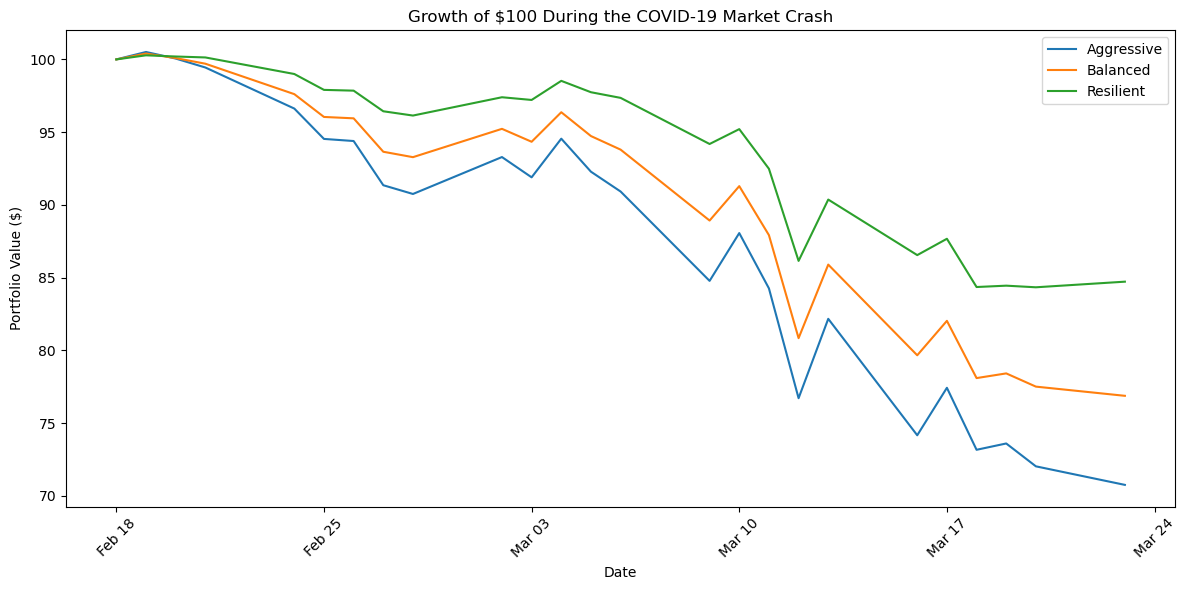

,Aggressive,Balanced,Resilient
2020-03-17 00:00:00,77.42,82.03,87.67
2020-03-18 00:00:00,73.16,78.09,84.35
2020-03-19 00:00:00,73.60,78.41,84.45
2020-03-20 00:00:00,72.03,77.50,84.33
2020-03-23 00:00:00,70.75,76.87,84.72


In [17]:
# Calculate growth of $100 during the COVID-19 Market Crash
covid_growth = growth_of_100_with_start(covid_returns)

# Plot growth of $100
plt.figure(figsize=(12, 6))

for column in covid_growth.columns:
    plt.plot(
        covid_growth.index,
        covid_growth[column],
        label=column
    )

plt.title("Growth of $100 During the COVID-19 Market Crash")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()

# Format x-axis dates
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
covid_growth.tail().style.format("{:.2f}")

In [18]:
# Calculate running maximum
covid_running_max = covid_growth.cummax()

# Calculate drawdowns
covid_drawdown = (
    covid_growth - covid_running_max
) / covid_running_max

# Calculate maximum drawdown
covid_max_drawdown = covid_drawdown.min()

# Display results
covid_max_drawdown_df = (
    covid_max_drawdown
    .to_frame(name="Maximum Drawdown")
    .style
    .format("{:.2%}")
)

covid_max_drawdown_df

,Maximum Drawdown
Aggressive,-29.61%
Balanced,-23.43%
Resilient,-15.90%


In [19]:
# COVID-19 drawdown analysis
covid_drawdown_analysis = []

for portfolio in portfolio_returns.columns:

    # Build an extended COVID series starting at the event
    # and continuing through the rest of the dataset
    extended_returns = portfolio_returns.loc[
        covid_start:,
        [portfolio]
    ]

    extended_growth = growth_of_100_with_start(
        extended_returns
    )[portfolio]

    # Restrict to COVID stress window for peak/trough analysis
    event_growth = extended_growth.loc[:covid_end]

    # Running peak and drawdown
    running_peak = event_growth.cummax()
    event_drawdown = (event_growth - running_peak) / running_peak

    # Trough date = maximum drawdown date
    trough_date = event_drawdown.idxmin()

    # Peak associated with that trough
    pre_trough_growth = event_growth.loc[:trough_date]
    peak_date = pre_trough_growth.idxmax()
    peak_value = pre_trough_growth.loc[peak_date]

    # Continue beyond event window using SAME rebased series
    after_trough = extended_growth.loc[trough_date:]

    # First date portfolio returns to or exceeds prior peak
    recovery_series = after_trough[
        after_trough >= peak_value
    ]

    if len(recovery_series) > 0:
        recovery_date = recovery_series.index[0]

        recovery_days = (recovery_date - trough_date).days
        drawdown_duration = (recovery_date - peak_date).days

    else:
        recovery_date = pd.NaT
        recovery_days = np.nan
        drawdown_duration = np.nan

    # Maximum drawdown
    max_drawdown = event_drawdown.min()

    covid_drawdown_analysis.append({
        "Portfolio": portfolio,
        "Maximum Drawdown": max_drawdown,
        "Peak Date": peak_date,
        "Trough Date": trough_date,
        "Recovery Date": recovery_date,
        "Recovery Days": recovery_days,
        "Drawdown Duration": drawdown_duration
    })

# Convert to DataFrame
covid_drawdown_df = pd.DataFrame(covid_drawdown_analysis)

#Clean the dates
date_columns = ["Peak Date", "Trough Date", "Recovery Date"]

for col in date_columns:
    covid_drawdown_df[col] = pd.to_datetime(
        covid_drawdown_df[col]
    ).dt.strftime("%Y-%m-%d")

In [20]:
#Convert Recovery periods to years
covid_drawdown_df["Recovery Years"] = (
    covid_drawdown_df["Recovery Days"] / 365.25
)

covid_drawdown_df["Drawdown Duration Years"] = (
    covid_drawdown_df["Drawdown Duration"] / 365.25
)
#Display
covid_drawdown_df.style.hide(axis="index").format({
    "Maximum Drawdown": "{:.2%}",
    "Recovery Days": "{:.0f}",
    "Drawdown Duration": "{:.0f}",
    "Recovery Years": "{:.2f}",
    "Drawdown Duration Years": "{:.2f}"
})

Portfolio,Maximum Drawdown,Peak Date,Trough Date,Recovery Date,Recovery Days,Drawdown Duration,Recovery Years,Drawdown Duration Years
Aggressive,-29.61%,2020-02-19,2020-03-23,2020-08-04,134,167,0.37,0.46
Balanced,-23.43%,2020-02-19,2020-03-23,2020-07-15,114,147,0.31,0.40
Resilient,-15.90%,2020-02-19,2020-03-20,2020-06-05,77,107,0.21,0.29


### Interpretation

The COVID-19 market crash produced a rapid decline across all three portfolios, but the severity of the loss differed considerably by allocation. Aggressive Growth experienced the largest cumulative loss and maximum drawdown, while Resilient Growth experienced the smallest.

Unlike the prolonged recovery following the Global Financial Crisis, all three portfolios recovered relatively quickly after the COVID-19 selloff. Resilient Growth experienced both the smallest drawdown and the shortest recovery period, while Aggressive Growth required the longest time to regain its previous peak.

This scenario shows that portfolio resilience depends not only on the size of the initial loss but also on how quickly the portfolio recovers after the stress event.

## 2022 Inflation and Rising-Rate Bear Market
The 2022 market downturn occurred amid persistently high inflation and a rapid tightening of monetary policy as central banks increased interest rates to address rising price pressures. Higher interest rates contributed to declines in both equity and fixed-income markets, creating a challenging environment for diversified portfolios. Unlike many traditional equity-market downturns, bonds provided less downside protection as rising yields simultaneously placed pressure on bond prices. This environment provides a useful historical example of a market shock in which multiple major asset classes experienced losses at the same time.

### Purpose
This historical stress scenario evaluates the performance and resilience of the Aggressive, Balanced, and Resilient Growth portfolios during the 2022 inflation and rising-rate market downturn. The analysis provides an opportunity to assess how the portfolios responded when both equities and fixed-income assets were under pressure. In particular, the scenario evaluates whether the greater bond allocation of the more defensive portfolios continued to provide meaningful downside protection in an environment characterized by rapidly rising interest rates and elevated inflation.

### Event Window Methodology
The 2022 Inflation and Rising-Rate Bear Market stress window is defined as January 3, 2022 through October 12, 2022, representing the major U.S. equity-market peak-to-trough decline during the 2022 market downturn. The period captures the effects of elevated inflation, rapidly tightening monetary policy, rising interest rates, and simultaneous pressure across equity and fixed-income markets. Portfolio performance is evaluated over this common stress window, while portfolio-specific peak and trough dates are identified for drawdown analysis. Recovery is measured beyond the event window until each portfolio regains its respective pre-drawdown peak.

In [21]:
# Define 2022 Inflation and Rising-Rate Bear Market stress window
inflation_start = "2022-01-03"
inflation_end = "2022-10-12"

# Extract portfolio returns during the stress window
inflation_returns = portfolio_returns.loc[
    inflation_start:inflation_end
]

# Validate event window
print(inflation_returns.index.min())
print(inflation_returns.index.max())
print(len(inflation_returns))

2022-01-03 00:00:00
2022-10-12 00:00:00
196


In [22]:
# Calculate cumulative return during the 2022 Inflation and Rising-Rate Bear Market
inflation_cumulative_return = (1 + inflation_returns).prod() - 1

# Display results
inflation_cumulative_return_df = (
    inflation_cumulative_return
    .to_frame(name="Cumulative Return")
    .style
    .format("{:.2%}")
)

inflation_cumulative_return_df

,Cumulative Return
Aggressive,-22.67%
Balanced,-20.52%
Resilient,-17.61%


### Growth of $100 Invested

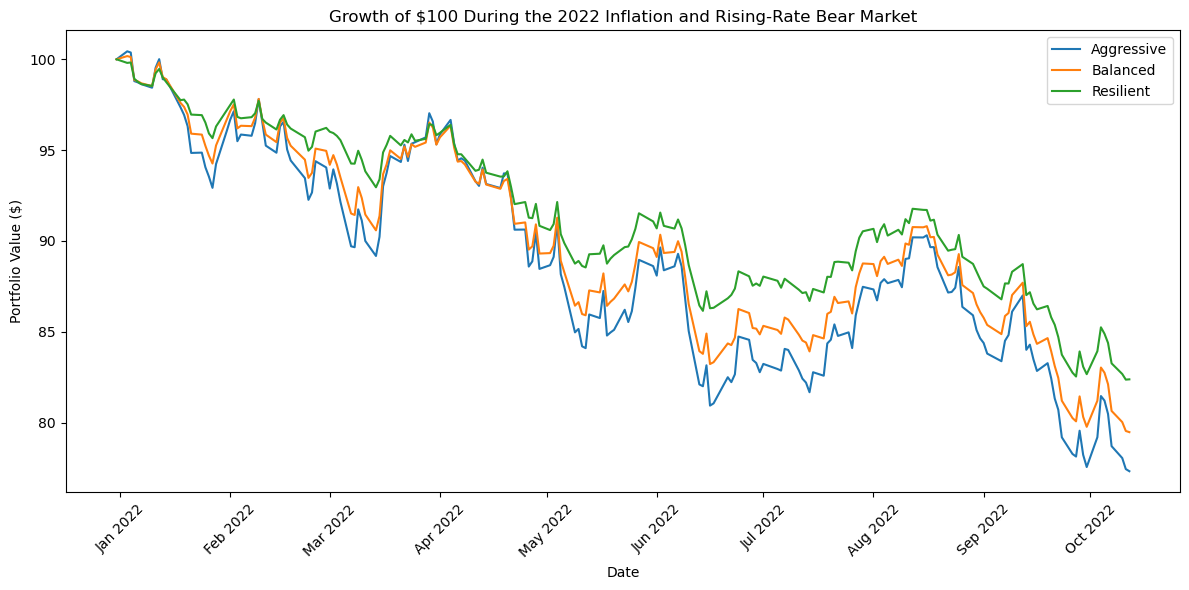

,Aggressive,Balanced,Resilient
2022-10-06 00:00:00,80.48,82.12,84.39
2022-10-07 00:00:00,78.71,80.65,83.27
2022-10-10 00:00:00,78.05,80.03,82.68
2022-10-11 00:00:00,77.45,79.54,82.37
2022-10-12 00:00:00,77.33,79.48,82.39


In [23]:
# Calculate growth of $100 during the 2022 Inflation and Rising-Rate Bear Market
inflation_growth = growth_of_100_with_start(inflation_returns)

# Plot growth of $100
plt.figure(figsize=(12, 6))

for column in inflation_growth.columns:
    plt.plot(
        inflation_growth.index,
        inflation_growth[column],
        label=column
    )

plt.title("Growth of $100 During the 2022 Inflation and Rising-Rate Bear Market")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()

# Format x-axis dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
inflation_growth.tail().style.format("{:.2f}")

In [24]:
# Calculate running maximum
inflation_running_max = inflation_growth.cummax()

# Calculate drawdowns
inflation_drawdown = (
    inflation_growth - inflation_running_max
) / inflation_running_max

# Calculate maximum drawdown
inflation_max_drawdown = inflation_drawdown.min()

# Display results
inflation_max_drawdown_df = (
    inflation_max_drawdown
    .to_frame(name="Maximum Drawdown")
    .style
    .format("{:.2%}")
)

inflation_max_drawdown_df

,Maximum Drawdown
Aggressive,-23.01%
Balanced,-20.66%
Resilient,-17.63%


In [25]:
# 2022 Inflation and Rising-Rate Bear Market drawdown analysis
inflation_drawdown_analysis = []

for portfolio in portfolio_returns.columns:

    # Use returns from the start of the event through the end of the full dataset
    extended_returns = portfolio_returns.loc[
        inflation_start:,
        [portfolio]
    ]

    # Rebase the entire event + recovery period to $100
    extended_growth = growth_of_100_with_start(
        extended_returns
    )[portfolio]

    # Restrict to the stress window for peak/trough analysis
    event_growth = extended_growth.loc[:inflation_end]

    # Calculate running peak and drawdown
    running_peak = event_growth.cummax()

    event_drawdown = (
        event_growth - running_peak
    ) / running_peak

    # Identify trough date
    trough_date = event_drawdown.idxmin()

    # Identify peak associated with that trough
    pre_trough_growth = event_growth.loc[:trough_date]

    peak_date = pre_trough_growth.idxmax()
    peak_value = pre_trough_growth.loc[peak_date]

    # Search forward from trough on SAME rebased growth series
    after_trough = extended_growth.loc[trough_date:]

    # First date portfolio regains prior peak
    recovery_series = after_trough[
        after_trough >= peak_value
    ]

    if len(recovery_series) > 0:

        recovery_date = recovery_series.index[0]

        recovery_days = (
            recovery_date - trough_date
        ).days

        drawdown_duration = (
            recovery_date - peak_date
        ).days

    else:

        recovery_date = pd.NaT
        recovery_days = np.nan
        drawdown_duration = np.nan

    # Maximum drawdown
    max_drawdown = event_drawdown.min()

    inflation_drawdown_analysis.append({
        "Portfolio": portfolio,
        "Maximum Drawdown": max_drawdown,
        "Peak Date": peak_date,
        "Trough Date": trough_date,
        "Recovery Date": recovery_date,
        "Recovery Days": recovery_days,
        "Drawdown Duration": drawdown_duration
    })

# Convert results to DataFrame
inflation_drawdown_df = pd.DataFrame(
    inflation_drawdown_analysis
)
# Format dates
date_columns = [
    "Peak Date",
    "Trough Date",
    "Recovery Date"
]

for col in date_columns:
    inflation_drawdown_df[col] = pd.to_datetime(
        inflation_drawdown_df[col]
    ).dt.strftime("%Y-%m-%d")


# Convert periods to years
inflation_drawdown_df["Recovery Years"] = (
    inflation_drawdown_df["Recovery Days"] / 365.25
)

inflation_drawdown_df["Drawdown Duration Years"] = (
    inflation_drawdown_df["Drawdown Duration"] / 365.25
)


# Display results
inflation_drawdown_df.style.hide(axis="index").format({
    "Maximum Drawdown": "{:.2%}",
    "Recovery Days": "{:.0f}",
    "Drawdown Duration": "{:.0f}",
    "Recovery Years": "{:.2f}",
    "Drawdown Duration Years": "{:.2f}"
})

Portfolio,Maximum Drawdown,Peak Date,Trough Date,Recovery Date,Recovery Days,Drawdown Duration,Recovery Years,Drawdown Duration Years
Aggressive,-23.01%,2022-01-03,2022-10-12,2023-12-27,441,723,1.21,1.98
Balanced,-20.66%,2022-01-03,2022-10-12,2024-02-09,485,767,1.33,2.10
Resilient,-17.63%,2021-12-31,2022-10-11,2024-03-06,512,796,1.40,2.18


### Interpretation

The 2022 inflation and rising-rate bear market produced meaningful losses across all three portfolios, but the differences in drawdown severity were narrower than during the Global Financial Crisis or COVID-19 shock. Aggressive Growth still experienced the largest cumulative loss and maximum drawdown, while Resilient Growth experienced the smallest.

The recovery pattern, however, was different. Despite experiencing the smallest initial drawdown, Resilient Growth required the longest period to regain its previous peak. Aggressive Growth experienced a larger decline but recovered sooner.

This is an important distinction because it shows that reducing the severity of a drawdown does not necessarily result in a faster recovery. In an environment where both equities and fixed-income assets were under pressure, portfolio resilience depended on both the magnitude and duration of the loss.

In [26]:
# Create historical stress testing summary table

stress_summary = pd.DataFrame({
    
    "Event": (
        ["Global Financial Crisis"] * 3 +
        ["European Sovereign Debt Crisis"] * 3 +
        ["COVID-19 Market Crash"] * 3 +
        ["2022 Inflation & Rising-Rate Bear Market"] * 3
    ),
    
    "Portfolio": (
        ["Aggressive", "Balanced", "Resilient"] * 4
    ),
    
    "Cumulative Return": (
        list(gfc_cumulative_return.values) +
        list(euro_cumulative_return.values) +
        list(covid_cumulative_return.values) +
        list(inflation_cumulative_return.values)
    ),
    
    "Maximum Drawdown": (
        list(gfc_max_drawdown.values) +
        list(euro_max_drawdown.values) +
        list(covid_max_drawdown.values) +
        list(inflation_max_drawdown.values)
    ),
    
    "Recovery Years": (
        list(gfc_drawdown_df["Recovery Years"]) +
        list(euro_drawdown_df["Recovery Years"]) +
        list(covid_drawdown_df["Recovery Years"]) +
        list(inflation_drawdown_df["Recovery Years"])
    ),
    
    "Drawdown Duration Years": (
        list(gfc_drawdown_df["Drawdown Duration Years"]) +
        list(euro_drawdown_df["Drawdown Duration Years"]) +
        list(covid_drawdown_df["Drawdown Duration Years"]) +
        list(inflation_drawdown_df["Drawdown Duration Years"])
    )
})

In [27]:
# Ending value of a hypothetical $100 investment
stress_summary["Ending Value of $100"] = (
    100 * (1 + stress_summary["Cumulative Return"])
)

In [28]:
#Order Variables
stress_summary = stress_summary[
    [
        "Event",
        "Portfolio",
        "Cumulative Return",
        "Ending Value of $100",
        "Maximum Drawdown",
        "Recovery Years",
        "Drawdown Duration Years"
    ]
]

In [29]:
#Display
display(
    stress_summary.style
    .hide(axis="index")
    .format({
        "Cumulative Return": "{:.2%}",
        "Ending Value of $100": "${:.2f}",
        "Maximum Drawdown": "{:.2%}",
        "Recovery Years": "{:.2f}",
        "Drawdown Duration Years": "{:.2f}"
    })
    .set_caption("Historical Stress Scenario Comparison")
)

Event,Portfolio,Cumulative Return,Ending Value of $100,Maximum Drawdown,Recovery Years,Drawdown Duration Years
Global Financial Crisis,Aggressive,-39.91%,$60.09,-50.09%,1.94,3.30
Global Financial Crisis,Balanced,-29.56%,$70.44,-39.49%,1.58,2.93
Global Financial Crisis,Resilient,-14.60%,$85.40,-25.77%,0.90,1.40
European Sovereign Debt Crisis,Aggressive,-11.99%,$88.01,-12.54%,0.26,0.45
European Sovereign Debt Crisis,Balanced,-8.40%,$91.60,-8.84%,0.23,0.42
European Sovereign Debt Crisis,Resilient,-3.94%,$96.06,-4.45%,0.20,0.28
COVID-19 Market Crash,Aggressive,-29.25%,$70.75,-29.61%,0.37,0.46
COVID-19 Market Crash,Balanced,-23.13%,$76.87,-23.43%,0.31,0.40
COVID-19 Market Crash,Resilient,-15.28%,$84.72,-15.90%,0.21,0.29
2022 Inflation & Rising-Rate Bear Market,Aggressive,-22.67%,$77.33,-23.01%,1.21,1.98


## Comparative Findings
The historical stress tests demonstrate a consistent relationship between portfolio risk exposure and drawdown severity. Across all four historical events, the Aggressive Growth portfolio experienced the largest cumulative loss and maximum drawdown, while the Resilient Growth portfolio experienced the smallest. The Balanced Growth portfolio generally remained between the two. This pattern suggests that the progressively more defensive strategic asset allocations were effective in reducing downside exposure across several different types of market stress.

The magnitude and duration of losses, however, varied considerably across events. The Global Financial Crisis represented the most severe overall stress event for the portfolios, producing the deepest maximum drawdowns and longest drawdown durations. In contrast, the COVID-19 market crash generated substantial losses over a much shorter period, followed by comparatively rapid recoveries. This distinction demonstrates that drawdown magnitude alone does not fully describe portfolio risk, as crises with similarly significant losses can differ substantially in the amount of time required for portfolios to recover.

The 2022 inflation and rising-rate bear market produced a different pattern. Although the Resilient Growth portfolio continued to experience the smallest cumulative loss and maximum drawdown, it required the longest recovery among the three portfolios. The Aggressive Growth portfolio experienced a larger initial decline but regained its previous peak sooner. This illustrates that greater downside protection does not necessarily imply faster recovery and highlights the importance of considering both drawdown severity and duration when evaluating portfolio resilience.

Overall, the results indicate that the more defensive strategic allocations reduced the severity of losses across the historical scenarios examined, although the degree of protection varied with the nature of the market shock. The findings reinforce the importance of evaluating portfolio risk across multiple stress environments rather than relying on performance during a single historical crisis.

## Conclusion

The historical scenario analysis shows that no single measure fully captures portfolio resilience. More defensive allocations generally reduced loss severity, but recovery behavior varied across different market environments.

These results provide a historical baseline for Notebook 5, where the analysis moves beyond observed crises and evaluates the portfolios under hypothetical stress scenarios, risk-factor sensitivities, and reverse stress testing.

In [30]:
stress_summary.to_csv(
    "historical_stress_testing_summary.csv",
    index=False
)